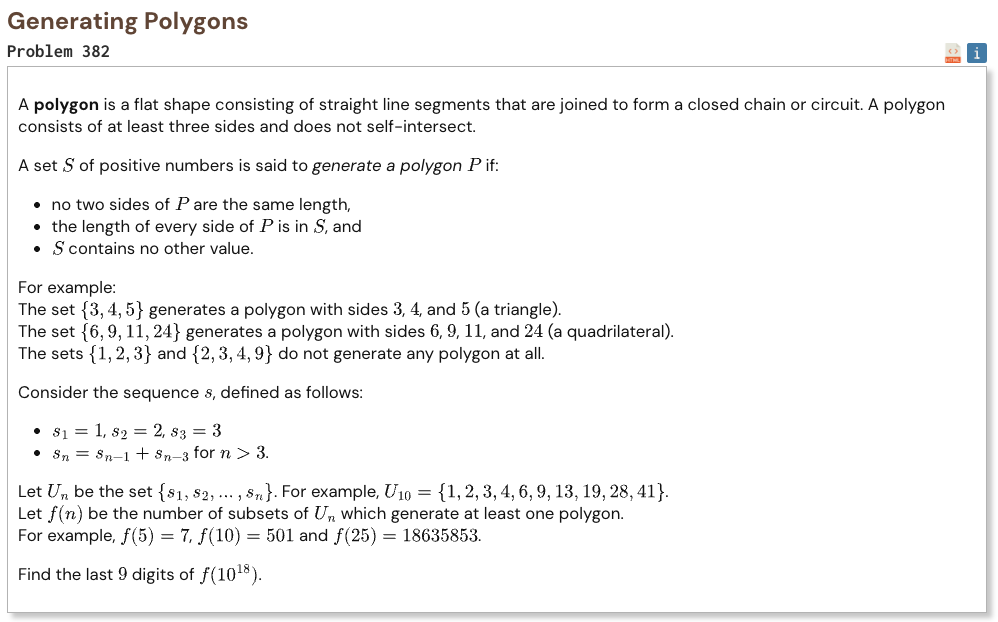

## Initial approach

* a set forms a polygon exactly when its largest value is smaller than the sum of all other values
* count the valid subsets by processing the sequence values from smallest to largest
* use two helper sequences to describe the invalid subsets whose largest side is too large
* the special recurrence of the side lengths makes these counting sequences follow short linear recurrences
* keep the cumulative total because f(n) counts valid subsets ending at every possible largest element
* include the current power of two in the state because several recurrence terms use it
* write the full update as a fixed matrix transformation
* raise the matrix to 10^18 - 5 with binary exponentiation modulo one billion

In [1]:
MOD = 10**9
TARGET = 10**18


def matrix_multiply(a, b):
    rows = len(a)
    middle = len(b)
    columns = len(b[0])
    result = [[0] * columns for _ in range(rows)]

    for i in range(rows):
        for k in range(middle):
            if a[i][k] == 0:
                continue

            for j in range(columns):
                result[i][j] += a[i][k] * b[k][j]
                result[i][j] %= MOD

    return result


def matrix_power(matrix, exponent):
    size = len(matrix)
    result = [[int(i == j) for j in range(size)] for i in range(size)]

    while exponent > 0:
        if exponent % 2 == 1:
            result = matrix_multiply(result, matrix)

        matrix = matrix_multiply(matrix, matrix)
        exponent //= 2

    return result


def solve(n):
    transition = [[0] * 11 for _ in range(11)]

    transition[0][2] = 1
    transition[0][3] = 1
    transition[0][6] = 1
    transition[0][8] = 14
    transition[0][10] = -2

    transition[1][0] = 1
    transition[2][1] = 1
    transition[3][2] = 1

    transition[4][3] = 1
    transition[4][6] = 1
    transition[4][8] = 2
    transition[4][10] = -1

    transition[5][4] = 1
    transition[6][5] = 1
    transition[7][6] = 1

    transition[8][8] = 2

    transition[9][2] = 1
    transition[9][3] = 1
    transition[9][6] = 1
    transition[9][8] = 14
    transition[9][9] = 1
    transition[9][10] = -2

    transition[10][10] = 1

    transition = [
        [value % MOD for value in row]
        for row in transition
    ]

    state = [
        [5],
        [2],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [7],
        [1],
    ]

    powered = matrix_power(transition, n - 5)
    final_state = matrix_multiply(powered, state)

    return final_state[9][0]


assert solve(5) == 7
assert solve(10) == 501
assert solve(25) == 18_635_853

In [2]:
%%time
result = solve(TARGET)
print("Result:", result)

Result: 697003956
CPU times: user 15 ms, sys: 365 μs, total: 15.3 ms
Wall time: 15.1 ms
